In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from cmdstanpy import CmdStanModel
import arviz as az

import nest_asyncio
nest_asyncio.apply()

c:\Users\guov2\miniconda3\envs\stan\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\guov2\miniconda3\envs\stan\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


11:37:41 - cmdstanpy - INFO - compiling stan file C:\Users\guov2\COGNIT~1\mpt_model.stan to exe file C:\Users\guov2\Cognitive Modeling\mpt_model.exe
11:37:58 - cmdstanpy - INFO - compiled model executable: C:\Users\guov2\Cognitive Modeling\mpt_model.exe
11:37:58 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]




chain 1:  66%|██████▌   | 2300/3500 [00:00<00:00, 22568.33it/s, (Sampling)]


chain 2: 100%|██████████| 3500/3500 [00:00<00:00, 24003.11it/s, (Sampling completed)]

chain 3: 100%|██████████| 3500/3500 [00:00<00:00, 24047.07it/s, (Sampling completed)]


chain 4: 100%|██████████| 3500/3500 [00:00<00:00, 24058.26it/s, (Sampling completed)]


11:37:59 - cmdstanpy - INFO - CmdStan done processing.



                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
d              0.267  0.167   0.000    0.553      0.002    0.001  4285.606   
g              0.331  0.116   0.111    0.538      0.002    0.001  4351.211   
theta[0]       0.258  0.059   0.152    0.372      0.001    0.000  8452.473   
theta[1]       0.165  0.058   0.055    0.269      0.001    0.001  4351.217   
theta[2]       0.335  0.058   0.231    0.445      0.001    0.001  4351.222   
theta[3]       0.242  0.059   0.128    0.348      0.001    0.000  8452.473   
pred_freqs[0]  5.198  2.255   1.000    9.000      0.023    0.016  9949.113   
pred_freqs[1]  3.293  2.003   0.000    7.000      0.023    0.015  7066.240   
pred_freqs[2]  6.670  2.399   3.000   11.000      0.026    0.018  8269.836   
pred_freqs[3]  4.838  2.230   0.000    8.000      0.023    0.016  9628.737   

               ess_tail  r_hat  
d              3166.722  1.000  
g              4730.063  1.001  
theta[0]       7380.466  1.000  
theta[1]

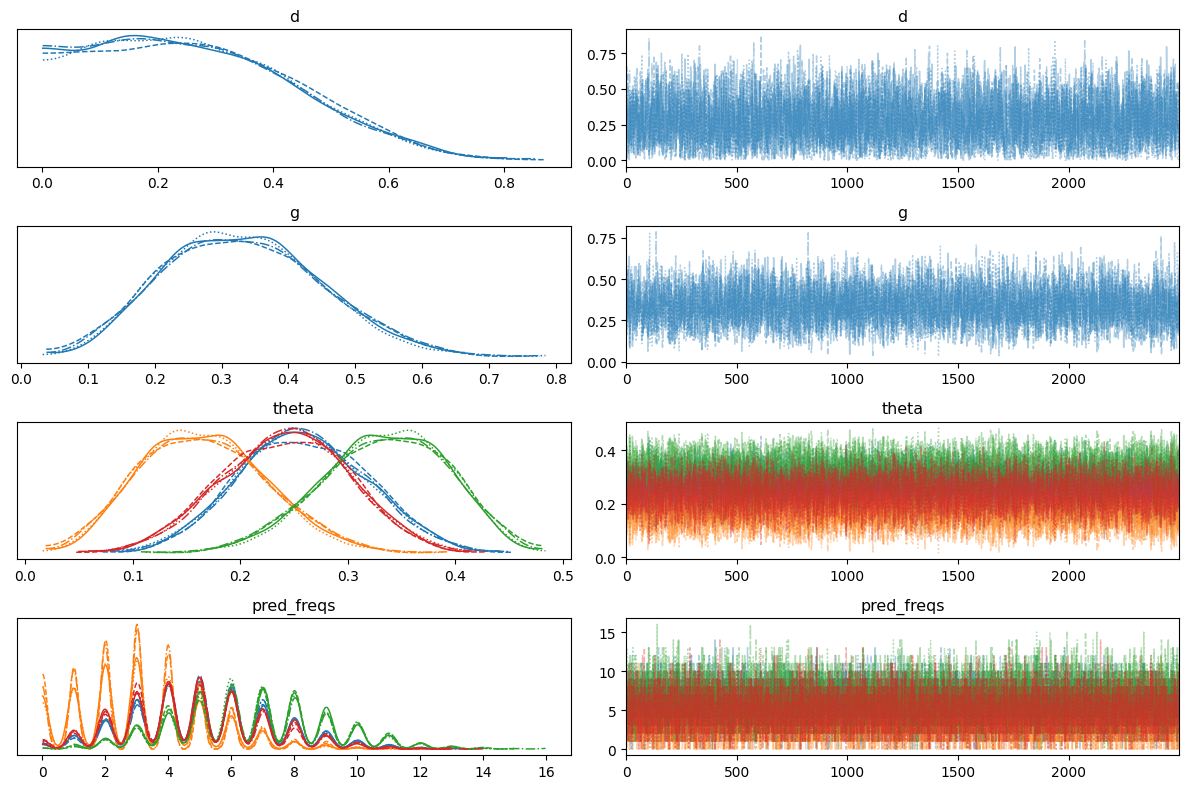

In [4]:

data = [5,3,6,6]

stan_dict = {
    'freqs': data,
    'N': 20,
    'K': 4
}

# -------------------------------
# Save the Stan model to a file
# -------------------------------
mpt_model_code = """
data {
  int<lower=1> N; // Number of trials
  int<lower=1> K; // Number of categories
  array[K] int<lower=0, upper=N> freqs;
}

parameters {
  real<lower = 0, upper=1> d;
  real<lower = 0, upper=1> g;
}

transformed parameters {
  simplex[4] theta;
  theta[1] = 0.5*(d + (1-d)*g);
  theta[2] = 0.5*g;
  theta[3] = 0.5*(1-g);
  theta[4] = 0.5*(1-d)*(1-g);
}

model {
  target += beta_lpdf(d | 1,1);
  target += beta_lpdf(g | 1,1);
  target += multinomial_lpmf(freqs | theta);
}

generated quantities {
  array[K] int pred_freqs;
  pred_freqs = multinomial_rng(theta, N);
}
"""

stan_file = "mpt_model.stan"
with open(stan_file, "w") as f:
    f.write(mpt_model_code)

# -------------------------------
# Compile the model
# -------------------------------
posterior = CmdStanModel(stan_file=stan_file)

# -------------------------------
# Sample from the posterior
# -------------------------------
fit = posterior.sample(
    data=stan_dict,
    chains=4,
    iter_sampling=2500,
    iter_warmup=1000,
    seed=42
)

# -------------------------------
# Convert to ArviZ for diagnostics
# -------------------------------
az_data = az.from_cmdstanpy(fit)

# Traceplot
azarr = az.plot_trace(fit)
plt.tight_layout()

# Posterior summary
print(az.summary(az_data, round_to=3))

In [10]:
ht2_mpt_model_code = """
data {
  int<lower=1> N; // Number of trials
  int<lower=1> K; // Number of categories
  array[K] int<lower=0, upper=N> freqs;
}

parameters {
  real<lower = 0, upper=1> d;
  real<lower = 0, upper=1> g;
}

transformed parameters {
  // Model equations go here
  // Prob. True Positive
  // Prob. False Positive
  // Prob. True Negative
  // Prob. False Negative
  simplex[4] theta;
  theta[1] = 0.5*(d+(1-d)*g);
  theta[2] = 0.5*((1-d)*g);
  theta[3] = 0.5*(d+(1-d)*(1-g));
  theta[4] = 0.5*((1-d)*(1-g));
}

model {
  target+=beta_lpdf(d| 1,1);
  target+=beta_lpdf(g | 1,1);
  target+=multinomial_lpmf(freqs | theta);
}

generated quantities{
  array[K] int pred_freqs;
  pred_freqs = multinomial_rng(theta, N);
}
"""

19:50:04 - cmdstanpy - INFO - compiling stan file C:\Users\guov2\COGNIT~1\ht2_mpt_model.stan to exe file C:\Users\guov2\Cognitive Modeling\ht2_mpt_model.exe
19:50:51 - cmdstanpy - INFO - compiled model executable: C:\Users\guov2\Cognitive Modeling\ht2_mpt_model.exe
19:50:51 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:00<00:00, 5806.68it/s, (Warmup)]


chain 1:  29%|██▊       | 1000/3500 [00:00<00:00, 5806.68it/s, (Sampling)]


chain 1:  49%|████▊     | 1700/3500 [00:00<00:00, 8529.23it/s, (Sampling)]


chain 1:  80%|████████  | 2800/3500 [00:00<00:00, 9266.74it/s, (Sampling)]


chain 2: 100%|██████████| 3500/3500 [00:00<00:00, 8303.58it/s, (Sampling completed)]

chain 3: 100%|██████████| 3500/3500 [00:00<00:00, 8324.77it/s, (Sampling completed)]


chain 4: 100%|██████████| 3500/3500 [00:00<00:00, 8386.41it/s, (Sampling completed)] 


19:50:52 - cmdstanpy - INFO - CmdStan done processing.



                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
d              0.224  0.140   0.001    0.463      0.002    0.001  4220.084   
g              0.382  0.122   0.148    0.602      0.002    0.001  5224.006   
theta[0]       0.261  0.061   0.154    0.378      0.001    0.001  6515.616   
theta[1]       0.149  0.056   0.047    0.252      0.001    0.001  4921.235   
theta[2]       0.351  0.056   0.248    0.453      0.001    0.001  4921.223   
theta[3]       0.239  0.061   0.122    0.346      0.001    0.001  6515.616   
pred_freqs[0]  5.224  2.290   1.000    9.000      0.024    0.016  9183.757   
pred_freqs[1]  2.975  1.916   0.000    6.000      0.022    0.015  7407.127   
pred_freqs[2]  7.027  2.407   3.000   11.000      0.026    0.017  8822.303   
pred_freqs[3]  4.774  2.234   0.000    8.000      0.024    0.016  8688.066   

               ess_tail  r_hat  
d              2868.820  1.001  
g              4464.752  1.001  
theta[0]       6541.712  1.001  
theta[1]

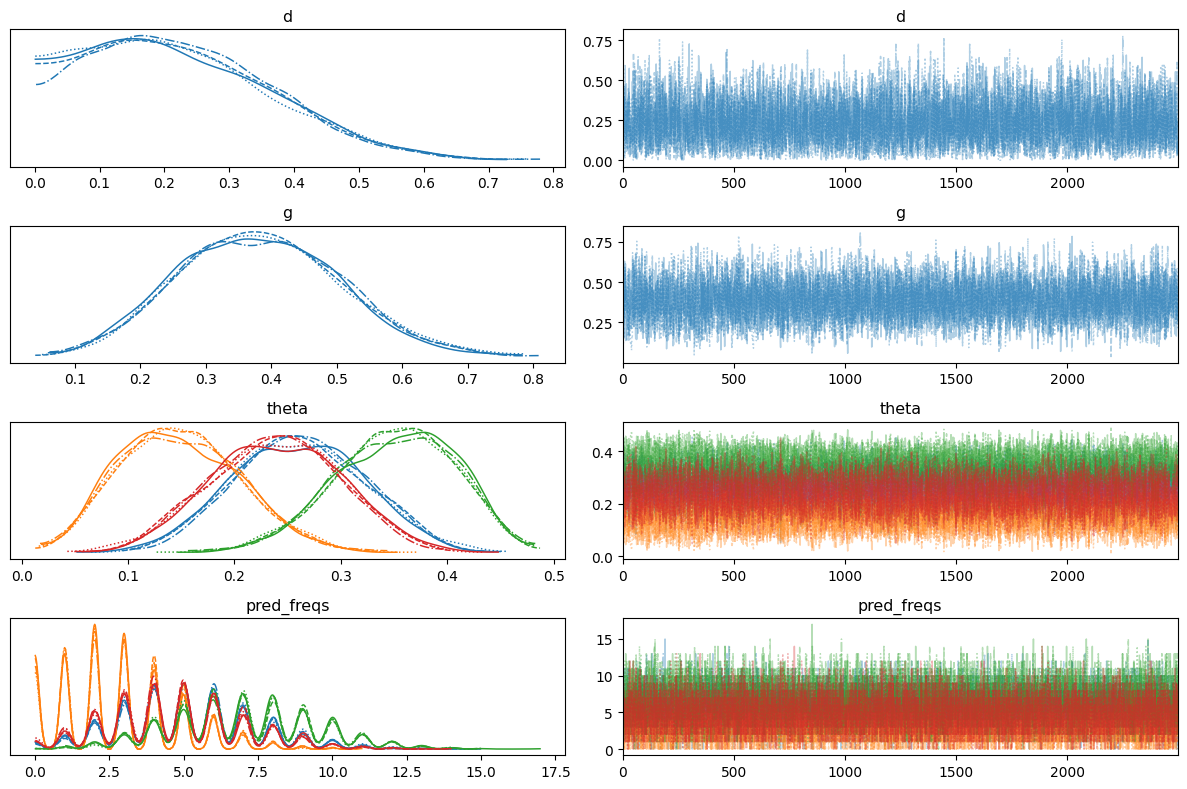

In [ ]:


# -------------------------------
# Save the Stan model to a file
# -------------------------------
ht2_stan_file = "ht2_mpt_model.stan"
with open(ht2_stan_file, "w") as f:
    f.write(ht2_mpt_model_code)

    # -------------------------------
    # Compile the model
    # -------------------------------
    ht2_posterior = CmdStanModel(stan_file=ht2_stan_file)

    # -------------------------------
    # Sample from the posterior
    # -------------------------------
    ht2_fit = ht2_posterior.sample(
        data=stan_dict,
            chains=4,
                iter_sampling=2500,
                    iter_warmup=1000,
                        seed=42
                        )

                        # -------------------------------
                        # Convert to ArviZ for diagnostics
                        # -------------------------------
                        ht2_az_data = az.from_cmdstanpy(ht2_fit)

                        # Traceplot
                        az.plot_trace(ht2_az_data)
                        plt.tight_layout()

                        # Posterior summary
                        print(az.summary(ht2_az_data, round_to=3))